#OBJECTIVE :-

To perform exploratory data analysis (EDA) on the Titanic dataset to identify patterns and factors that influenced passenger survival, such as gender, passenger class, age, fare, and family size.

# PROJECT:-
In this project I explored the titanic dataset to understand the factors affecting passenger survival through visualizations, summary-statistics, and feature based analysis.

#Key Research Questions:-
1. What is distribution of the passengers on the ship?

2. What is survival rates and does it differ between genders and age groups?Does resuce priortize passengers based on class? And was there any difference in survival rates compared between different family sizes?

3. What is the fair distribution? Does first class passengers charged more price than second and third class passengers?

4. Is there any correlation or relationship in between columns? And is the relationship inverse or direct?

# Relevant columns :-   
Distribution of man, woman, child --> who , sex, age_classification.

Survival rate on basis of gender, age --> age, survived, class, sex, age_classification, family-size.

Fair distribution on basis of class --> fare, class, sex, family_size.

Relationship or correlation in between columns --> class, age, sex, fare, survived, family_size, embark_town.

# Importing relevant libraries :-

In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Loading the data from seaborn :-

In [ ]:
# fetching the data
titanic_data = sns.load_dataset('titanic')
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Basic Inspection:-

In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   sex          891 non-null    object  
 2   age          714 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   class        891 non-null    category
 7   who          891 non-null    object  
 8   adult_male   891 non-null    bool    
 9   deck         203 non-null    category
 10  embark_town  889 non-null    object  
 11  alive        891 non-null    object  
 12  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(3), object(4)
memory usage: 66.7+ KB


In [ ]:
titanic_data.shape

(891, 13)

In [ ]:
titanic_data.columns

Index(['survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who',
       'adult_male', 'deck', 'embark_town', 'alive', 'alone'],
      dtype='object')

In [ ]:
titanic_data.describe()
# here we can see age has null values

,survived,age,sibsp,parch,fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
titanic_data['embark_town'].value_counts()

,count
embark_town,
Southampton,644
Cherbourg,168
Queenstown,77


In [ ]:
titanic_data['embarked'].value_counts()

KeyError: 'embarked'

# Data cleaning:-

# Searching and handling duplicates:-

In [ ]:
titanic_data[['embarked','embark_town']].value_counts()
# here we can see that embarked has just intials of embark_town so we are going to drop entire column

,,count
embarked,embark_town,
S,Southampton,644
C,Cherbourg,168
Q,Queenstown,77


In [ ]:
titanic_data.drop(columns = ['embarked'],axis = 1,inplace = True)

In [ ]:
titanic_data.columns # dropped the column

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class',
       'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'],
      dtype='object')

In [ ]:
titanic_data[['class','pclass']].value_counts() # here we have class and pclass as same so we can drop it too

,,count
class,pclass,
Third,3,491
First,1,216
Second,2,184


In [ ]:
titanic_data.drop(columns = ['pclass'],inplace = True,axis =1)

In [ ]:
titanic_data.columns

Index(['survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who',
       'adult_male', 'deck', 'embark_town', 'alive', 'alone'],
      dtype='object')

In [ ]:
titanic_data[titanic_data.duplicated()] # so we have duplicated rows 107 of them. but fare is different for them.
# but we dont want fare so we are going to take just relevant columns now.

,survived,sex,age,sibsp,parch,fare,class,who,adult_male,deck,embark_town,alive,alone
47,1,female,NaN,0,0,7.7500,Third,woman,False,NaN,Queenstown,yes,True
76,0,male,NaN,0,0,7.8958,Third,man,True,NaN,Southampton,no,True
77,0,male,NaN,0,0,8.0500,Third,man,True,NaN,Southampton,no,True
87,0,male,NaN,0,0,8.0500,Third,man,True,NaN,Southampton,no,True
95,0,male,NaN,0,0,8.0500,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,male,26.0,0,0,7.8958,Third,man,True,NaN,Southampton,no,True
877,0,male,19.0,0,0,7.8958,Third,man,True,NaN,Southampton,no,True
878,0,male,NaN,0,0,7.8958,Third,man,True,NaN,Southampton,no,True
884,0,male,25.0,0,0,7.0500,Third,man,True,NaN,Southampton,no,True


In [ ]:
titanic_data_subset = titanic_data[['survived','sex','age','sibsp','parch','fare','class','who','embark_town','alive','alone']]

In [ ]:
titanic_data_subset.columns

Index(['survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who',
       'embark_town', 'alive', 'alone'],
      dtype='object')

In [ ]:
titanic_data_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   sex          891 non-null    object  
 2   age          714 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   class        891 non-null    category
 7   who          891 non-null    object  
 8   embark_town  889 non-null    object  
 9   alive        891 non-null    object  
 10  alone        891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(3), object(4)
memory usage: 64.6+ KB


In [ ]:
titanic_data_subset[titanic_data_subset.duplicated()] # here we have duplicate values but not all the values

,survived,sex,age,sibsp,parch,fare,class,who,embark_town,alive,alone
47,1,female,NaN,0,0,7.7500,Third,woman,Queenstown,yes,True
76,0,male,NaN,0,0,7.8958,Third,man,Southampton,no,True
77,0,male,NaN,0,0,8.0500,Third,man,Southampton,no,True
87,0,male,NaN,0,0,8.0500,Third,man,Southampton,no,True
95,0,male,NaN,0,0,8.0500,Third,man,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
870,0,male,26.0,0,0,7.8958,Third,man,Southampton,no,True
877,0,male,19.0,0,0,7.8958,Third,man,Southampton,no,True
878,0,male,NaN,0,0,7.8958,Third,man,Southampton,no,True
884,0,male,25.0,0,0,7.0500,Third,man,Southampton,no,True


# Finding and handling missing values:-


In [ ]:
titanic_data_subset.isnull().sum() # we have 2 in emabark_town and 177 in age so we are going to drop embark_town ones first.

,0
survived,0
sex,0
age,177
sibsp,0
parch,0
fare,0
class,0
who,0
embark_town,2
alive,0


In [ ]:
titanic_data_subset.dropna(subset = ['embark_town'],inplace = True)

In [ ]:
titanic_data_subset['embark_town'].isnull().sum()

np.int64(0)

In [ ]:
titanic_data_subset['age'].isnull().mean()*100 # so there are almost 20% rows of null values in age column.
# which is a lot and also it is a critical column so we are going to impute it using mean or median.

np.float64(19.910011248593925)

In [ ]:
titanic_data_subset['age'].describe() # so the mean is 29 and median is 28 which is normal like not a hike or fall but
# we will check if there are any difference based on sex and classes.

,age
count,712.000000
mean,29.642093
std,14.492933
min,0.420000
25%,20.000000
50%,28.000000
75%,38.000000
max,80.000000


In [ ]:
titanic_data_subset.groupby(['class','sex'])['age'].agg({'mean','median'})
# here we can see the difference in median and mean of age is huge as there are older people in first class as compared to second and third class.

mean  median
class  sex                      
First  female  34.240964    35.0
       male    41.281386    40.0
Second female  28.722973    28.0
       male    30.740707    30.0
Third  female  21.750000    21.5
       male    26.507589    25.0

In [ ]:
# imputing the missing values in age using median according to class and sex
titanic_data_subset['age'] = titanic_data_subset['age'].fillna(titanic_data_subset.groupby(['class','sex'])['age'].transform('median'))

In [ ]:
titanic_data_subset['age'].isnull().sum() # now there are no further null values

np.int64(0)

In [ ]:
titanic_data_subset.head()

,survived,sex,age,sibsp,parch,fare,class,who,embark_town,alive,alone
0,0,male,22.0,1,0,7.2500,Third,man,Southampton,no,False
1,1,female,38.0,1,0,71.2833,First,woman,Cherbourg,yes,False
2,1,female,26.0,0,0,7.9250,Third,woman,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,First,woman,Southampton,yes,False
4,0,male,35.0,0,0,8.0500,Third,man,Southampton,no,True


# Feature Engineering :- Creating new columns for categorization

In [ ]:
# creating a new column for age categorization
# defining function first
def age_classification(age):
  if age <= 14:
    return 'Kid'
  elif age >= 15 and age <= 24:
    return 'youth'
  elif age >= 25 and age <= 64:
    return 'adults'
  else:
    return 'seniors'

titanic_data_subset['age_classified']=titanic_data_subset['age'].apply(age_classification)

In [ ]:
titanic_data_subset['age_classified'].value_counts() # here we can see that the there are majority of adults and then youth or teens.

,count
age_classified,
adults,558
youth,241
Kid,77
seniors,13


In [ ]:
# creating another column for family size :-
titanic_data_subset['family_size'] = titanic_data_subset['sibsp'] + titanic_data_subset['parch'] + 1 # 1 for person himself

In [ ]:
titanic_data_subset['family_size'].value_counts().sort_values()

,count
family_size,
8,6
11,7
7,12
5,15
6,22
4,29
3,102
2,161
1,535


In [ ]:
titanic_data_subset.head()

,survived,sex,age,sibsp,parch,fare,class,who,embark_town,alive,alone,age_classified,family_size
0,0,male,22.0,1,0,7.2500,Third,man,Southampton,no,False,youth,2
1,1,female,38.0,1,0,71.2833,First,woman,Cherbourg,yes,False,adults,2
2,1,female,26.0,0,0,7.9250,Third,woman,Southampton,yes,True,adults,1
3,1,female,35.0,1,0,53.1000,First,woman,Southampton,yes,False,adults,2
4,0,male,35.0,0,0,8.0500,Third,man,Southampton,no,True,adults,1


# VISUALIZATIONS:-

#Establish the Problem Statement:-

# 1. Distribution of man ,woman and child and further distribution on basis of gender and age_classification

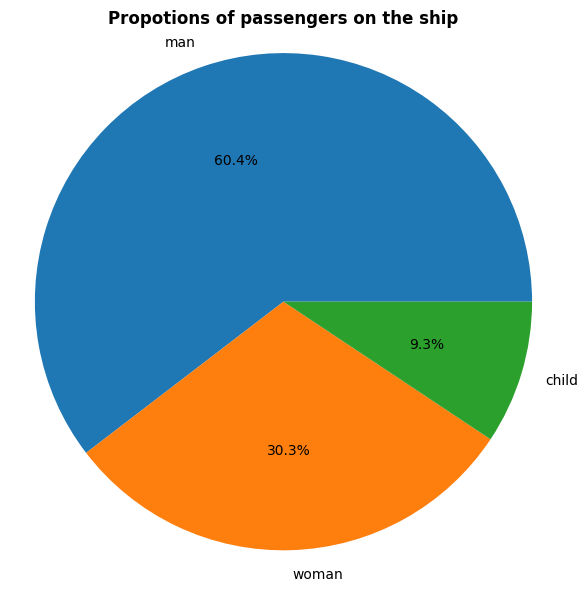

In [ ]:
# piechart to shows proportions of passengers on the ship
who_counts = titanic_data_subset['who'].value_counts()

plt.figure(figsize = (6,6))
plt.pie(who_counts,labels = who_counts.index,autopct = '%1.1f%%',labeldistance = 1.1)
plt.title('Propotions of passengers on the ship',fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.axis('equal')
plt.tight_layout()
plt.show()

Insights from the chart:-
1. This chart shows the proportion of the passengers by gender men comprising almost 60% of the total, almost 30% women and children just 9%.

2. This spark disparity highlightings that children and women were minority on the ship with men making up the majority of passengers.


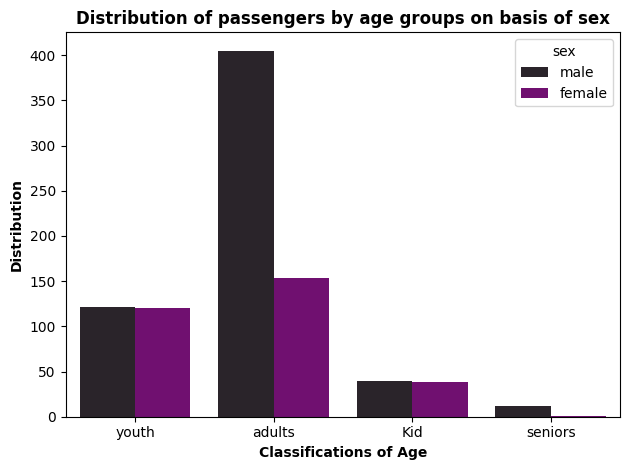

In [ ]:
# countplot to shows distribution of age groups on basis of sex
sns.countplot(data=titanic_data_subset,x='age_classified',hue='sex',color = 'purple')
plt.title('Distribution of passengers by age groups on basis of sex',fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.xlabel('Classifications of Age',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.ylabel('Distribution',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.tight_layout()
plt.show()


Insight from the chart:-
1. This chart illustrates the distribution of passengers across age groups, broken down by sex.

2. Adults represent the largest group, with over 550 passengers followed by youth numbering around 250, then kids at about 90 and seniors making up the smallest group with fewer than 25.

3. The chart reveals that males adults significantly outnumber femal adults, surpassing any other age-sex group combination.

4. In contrast among youth and kid, the female and male number are nearly equal suggestung a notable balance in these younger age groups.

5. Seniors however are much fewer in number, with no female seniors on board; this group is almost entirely male, but still very small.

# 2. What is survival rates and does it differ between genders and age groups?And does the resuce priortized on basis of class? And was there any difference in survival rates compared between different family sizes?

In [ ]:
survived_age_classify = titanic_data_subset.groupby(['age_classified','sex'])['survived'].mean().reset_index()

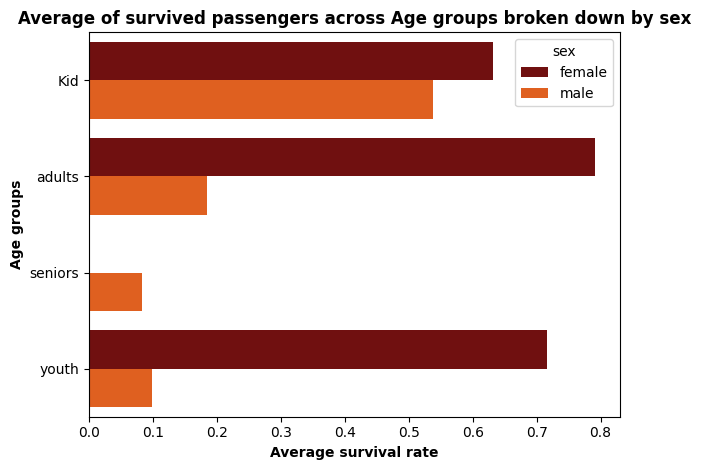

In [ ]:
# barplot to show average of survival rate of age groups broken down by sex
sns.barplot(data = survived_age_classify,x='survived',y='age_classified',hue='sex',palette = 'gist_heat')
plt.title("Average of survived passengers across Age groups broken down by sex",fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.xlabel('Average survival rate',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.ylabel('Age groups',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.tight_layout()
plt.show()

Insights from the chart:-
1. The bar plot showing the average survival rate by age group, broken down by sex.
2. The data reveals that adult females had the highest average survival rate among all age groups followed by youth females.
3. Children regardless of sex alos exhibited strong survival rates.
4. Youth females similarly showed high survival rates. In contrast both adult and youth males had lower survival rates, likely due to prioritization of women and children during the rescue.

In [ ]:
survived_class_sex = titanic_data_subset.groupby(['class','sex'])['survived'].mean().reset_index()

In [ ]:
survived_class_sex

,class,sex,survived
0,First,female,0.967391
1,First,male,0.368852
2,Second,female,0.921053
3,Second,male,0.157407
4,Third,female,0.500000
5,Third,male,0.135447


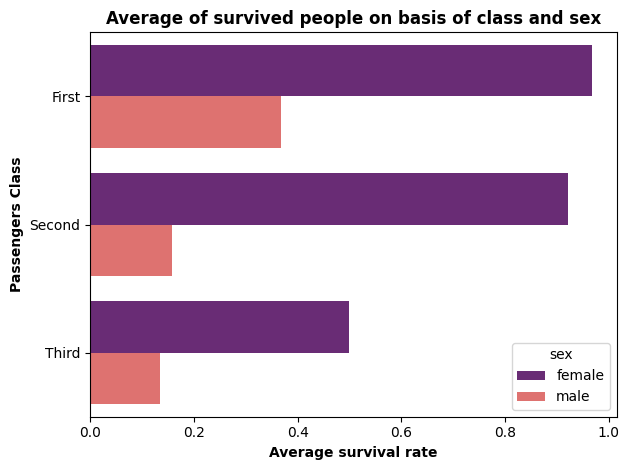

In [ ]:
# barplot to show average survival rate across class broken down by sex
sns.barplot(data = survived_class_sex,x='survived',y='class',hue='sex',palette = 'magma')
plt.title("Average of survived people on basis of class and sex",fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.xlabel('Average survival rate',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.ylabel('Passengers Class',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.tight_layout()
plt.show()

Insights from the chart:-
1. This barplot shows average survival rate acorss classes broken down by sex.
2. Females in both first and second classes were distinctly prioritized, achieving much higher survival-rates compared to third class females, whose survival rate was significantly lower.
3. Similarly first class males also had a relatively strong survival rate, while males in second and third class showed much lower survival-both below 0.2. Notably, first class males reached an average survival rate of 0.4.

4. Overall, when considering both genders, passengers in first and second classes had significantly higher survival rates compared to those in third class, regardless of gender.

In [ ]:
titanic_data_subset['family_size'].value_counts()

,count
family_size,
1,535
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


In [ ]:
# Defining a function to catgeorize family sizes
def familysize_classification(size):
  if size == 1:
    return 'Individual'
  elif size > 1 and size <= 2:
    return 'Two person family'
  elif size > 2 and size <= 4:
    return 'Small family'
  elif size >= 5 and size <= 6:
    return 'Medium family'
  else:
    return 'Big Family'

# Creating another column for familysize classification
titanic_data_subset['Family_size_grouped'] = titanic_data_subset['family_size'].apply(familysize_classification)
titanic_data_subset['Family_size_grouped'].value_counts()

,count
Family_size_grouped,
Individual,535
Two person family,161
Small family,131
Medium family,37
Big Family,25


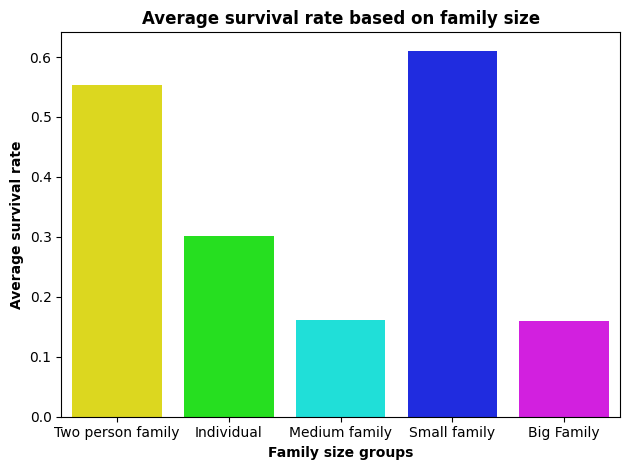

In [ ]:
# bar plot showing average survival rate across family size
sns.barplot(x='Family_size_grouped',data = titanic_data_subset,y='survived',palette = 'hsv',errorbar=None)
plt.xlabel('Family size groups',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.ylabel('Average survival rate',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Average survival rate based on family size',fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.tight_layout()
plt.show()

Insights from the chart:-
1. Barplot showing average survival rate based on family sizes.
2. Notably, families with two members and small families had highest average survival rates, exceeding 0.5. In contrast, individuals traveling alone had a much lower survival rate, around 0.3. Furthermore, the lowest survival rates were seen in medium and big families, both below 0.2.
3. A key limitation is that the distribution of family sizes is highly uneven- there are far more individuals traveling alone, while small families and larger families are much less frequent. This imbalance in family size distribution could affect the average survival rates, potentially skewing the overall interpretation of the chart.

# 3. What is the fare distribution? Does first class passengers charged more price than second and third class?

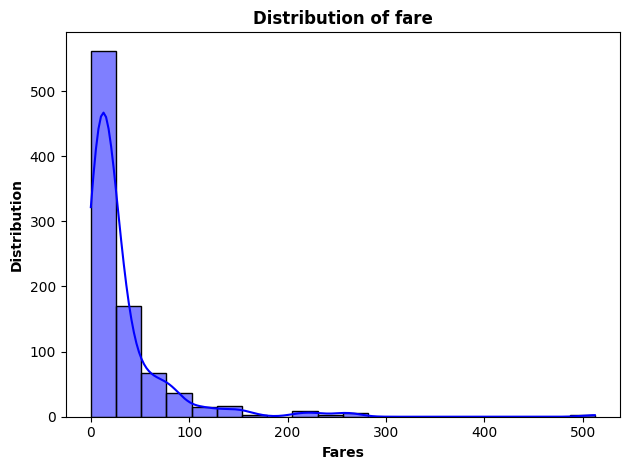

In [ ]:
# Overall fare distribution using histogram
sns.histplot(x='fare',data =titanic_data_subset,kde = True,bins = 20,color ='blue')
plt.title('Distribution of fare',fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.xlabel('Fares',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.ylabel('Distribution',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.tight_layout()
plt.show()

Insights from the chart:-
1. Histogram showing fare distribution.
2. The histogram shows that the fare distribution is right-skewed which the majority of fares concentrated between 0 and 100.
3. Almost all passengers paid fares with this range and there are only a few outliers above 200.
4. The most significant outlier is a fare of 500 which stands well apart from the rest of the data.
5. Overall skewness suggests that most passengers paid relatively low fares, while a small group of passengers with high fares may have had access to premium services.

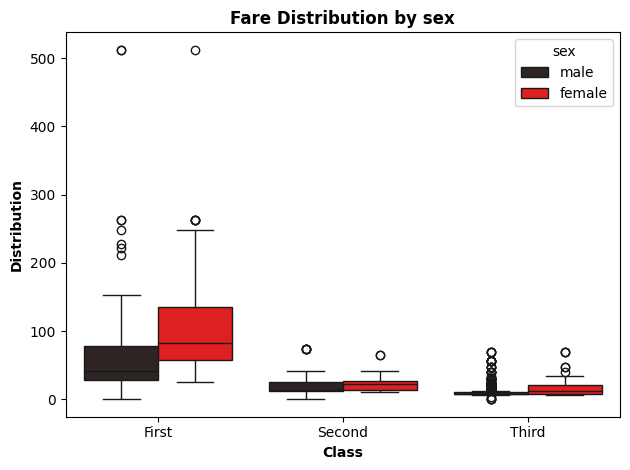

In [ ]:
# boxplot showing fare distribution across class borken down by sex
sns.boxplot(x='class',y='fare',data =titanic_data_subset,color ='red',hue ='sex')
plt.title('Fare Distribution by acorss class broken down by sex',fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.xlabel('Class',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.ylabel('Distribution',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.tight_layout()
plt.show()

Insights from the chart:-
1. Boxplot shows the distribution of fare acorss classes fruther broken down by sex.
2. The box plot reveals that first-class passengers paid significantly higher fares compared to those in second and third class; both male and female first-class fares show outliers reaching as high as 500.
3. Even within first class, some passengers paid far above the average, suggesting they may have had access to premium accommodations or special services.
4. In contrast, passengers in second and third class generally paid similar amounts; however, there are a few male third-class passengers who paid noticeably different amounts, appearing as outliers in the plot.

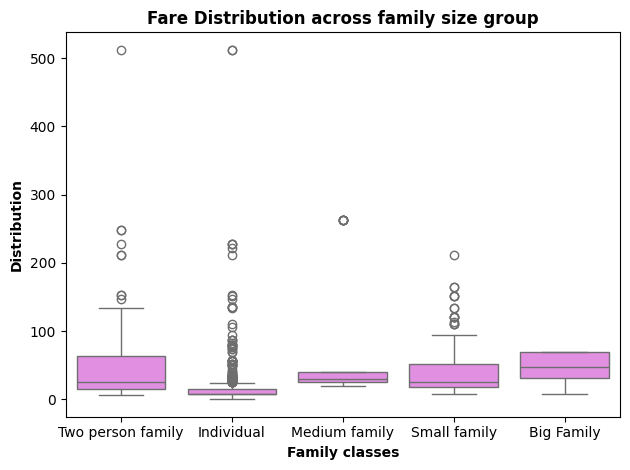

In [ ]:
# boxplot showing fare distribution acorss family size groups.
sns.boxplot(x='Family_size_grouped',y='fare',data =titanic_data_subset,color ='violet')
plt.title('Fare Distribution across family size group',fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.xlabel('Family classes',fontdict={'fontsize': 10, 'fontweight': 'bold'})
plt.ylabel('Distribution',fontdict={'fontsize': 10, 'fontweight': 'bold'})
#plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Insights from the chart:-
1. This box plot illustrates the fare distribution across different family size groups.
2. Some individuals and two-person families paid notably higher fares; this may be because they included first-class passengers traveling alone, which raised their average.
3. Although big families were expected to spend more, this was not the case; instead, big families largely belonged to second and third class, which kept their fare levels lower.

# 4. Is there any correlation or relationship in between columns? And is the relationship inverse or direct?

In [ ]:
titanic_data_subset.head()

,survived,sex,age,sibsp,parch,fare,class,who,embark_town,alive,alone,age_classified,family_size,Family_size_grouped
0,0,male,22.0,1,0,7.2500,Third,man,Southampton,no,False,youth,2,Two person family
1,1,female,38.0,1,0,71.2833,First,woman,Cherbourg,yes,False,adults,2,Two person family
2,1,female,26.0,0,0,7.9250,Third,woman,Southampton,yes,True,adults,1,Individual
3,1,female,35.0,1,0,53.1000,First,woman,Southampton,yes,False,adults,2,Two person family
4,0,male,35.0,0,0,8.0500,Third,man,Southampton,no,True,adults,1,Individual


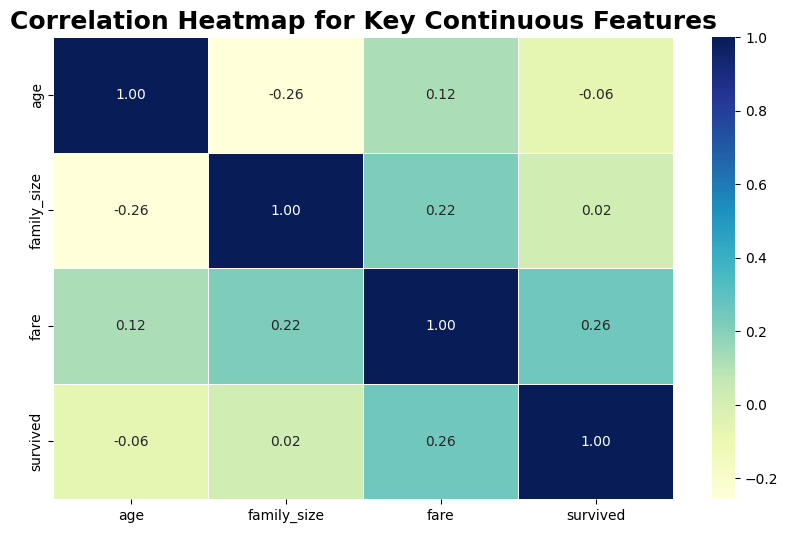

In [ ]:
# correlation heatmap to find relationship betwenn continous columns
plt.figure(figsize=(10, 6))
correlation_matrix = titanic_data_subset[['age','family_size','fare','survived']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Key Continuous Features', fontsize=18, fontweight='bold')
plt.show()

Insights from the chart:-
1. This heatmap presents a correlation analysis between continuous variables such as age, family size, fare, and survival.
2. Overall, the correlations between these variables are moderate to weak, indicating that they are largely independent on a broad scale.
3. However, a closer look reveals a slight positive correlation between fare and survival, suggesting that those who paid higher fares had a somewhat greater likelihood of survival.

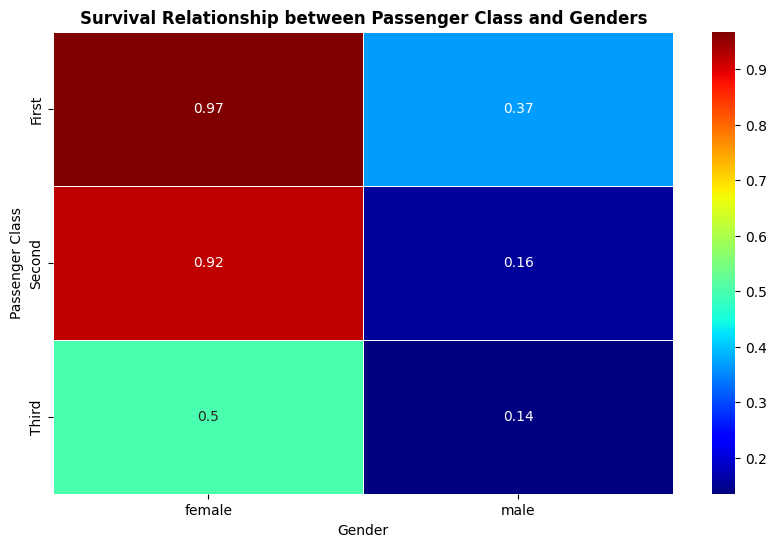

In [ ]:
#
plt.figure(figsize = (10,6))
pivot_table = titanic_data_subset.pivot_table(columns = 'sex',values = 'survived',index = 'class',aggfunc = 'mean')
pivot_table.index.name = 'Passenger Class'
pivot_table.columns.name = 'Gender'
sns.heatmap(pivot_table, annot=True, cmap="jet", linewidths=0.5)
plt.title('Survival Relationship between Passenger Class and Genders',fontsize=12, fontweight='bold')
plt.show()

Insights from the chart:-
1. This chart visualizes the relationship between survival rates across gender and passenger class.
2. A key finding is that females in first and second class had markedly higher survival rates than those in third class, likely due to both financial capacity and prioritization.
3. In contrast, males had consistently lower survival rates than females across all classes, reinforcing that women were given greater priority.
4. Additionally, first-class males had higher survival rates than their counterparts in second and third class, suggesting that class-based prioritization played a significant role in survival outcomes.

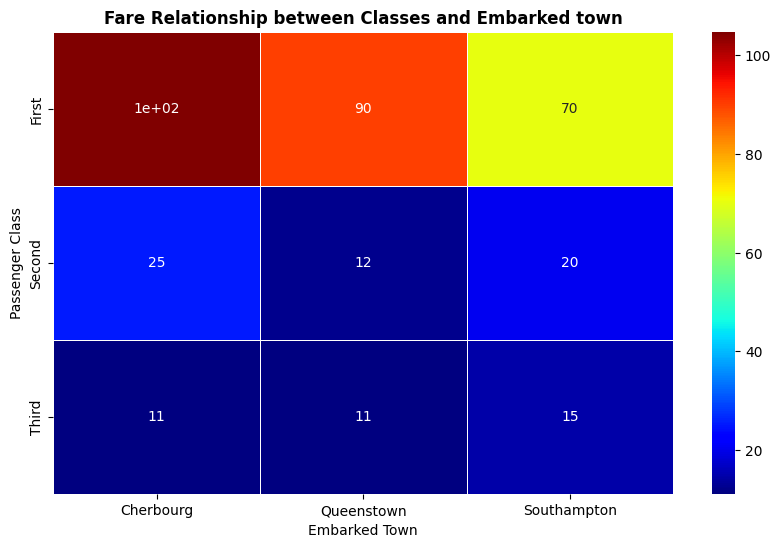

In [ ]:
# creating heatmap to show relationship between classes and embarked towns.
plt.figure(figsize = (10,6))
# creating pivot table to prepare the data first for the heatmap
pivot_table = titanic_data_subset.pivot_table(columns = 'embark_town',values = 'fare',index = 'class',aggfunc = 'mean')
pivot_table.index.name = 'Passenger Class'
pivot_table.columns.name = 'Embarked Town'
sns.heatmap(pivot_table, annot=True, cmap="jet", linewidths=0.5)
plt.title('Fare Relationship between Classes and Embarked town',fontsize=12, fontweight='bold')
plt.show()

Insights from the chart:-
1. This heatmap visualizes the relationship between fare and passenger class across different embarkation towns.
2. As expected, first-class passengers were charged significantly higher fares than those in second and third class.
3. However, the towns themselves did not show a strong direct relationship with fare prices; the class had a much more pronounced effect.
4. An unexpected anomaly appears in the fare for first-class passengers from the Cherbourg town, where an unusually high value (around 1E+02) is observed. This outlier might be due to a data entry error or some extraordinary circumstance, and it stands out against the general pattern.

# Critical finding from the data :-  

In [ ]:
titanic_data_subset[(titanic_data_subset['age']<=15.0) & (titanic_data_subset['Family_size_grouped']=='Individual')]
# here it shows there were 6 childrens to be precise that were alone on the ship which is quiet unusual

,survived,sex,age,sibsp,parch,fare,class,who,embark_town,alive,alone,age_classified,family_size,Family_size_grouped
14,0,female,14.0,0,0,7.8542,Third,child,Southampton,no,True,Kid,1,Individual
22,1,female,15.0,0,0,8.0292,Third,child,Queenstown,yes,True,youth,1,Individual
731,0,male,11.0,0,0,18.7875,Third,child,Cherbourg,no,True,Kid,1,Individual
777,1,female,5.0,0,0,12.4750,Third,child,Southampton,yes,True,Kid,1,Individual
780,1,female,13.0,0,0,7.2292,Third,child,Cherbourg,yes,True,Kid,1,Individual
875,1,female,15.0,0,0,7.2250,Third,child,Cherbourg,yes,True,youth,1,Individual


In [ ]:
# taking only child data in another variable
child_grouped = titanic_data_subset[titanic_data_subset['who']=='child']

In [ ]:
child_alone = child_grouped['alone'].value_counts() # preparing the data for the piechart visual

In [ ]:
child_alone # checking the data

,count
alone,
False,77
True,6


In [ ]:
child_grouped[['class']].value_counts() # just checking the class based childrens

,count
class,
Third,58
Second,19
First,6


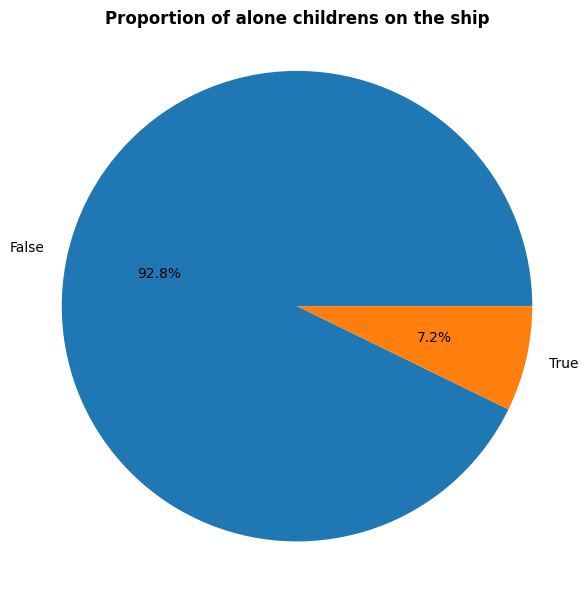

In [ ]:
plt.figure(figsize = (6,6))
plt.pie(child_alone,labels = child_alone.index,autopct = '%1.1f%%',labeldistance = 1.1)
plt.title('Proportion of alone childrens on the ship',fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.axis('equal')
plt.tight_layout()
plt.show()

Insights from the chart:-
1. Chart shows the proportions of child that were alone or not on the ship.
2. It shows some childrens 7.2% were alone which is quiet unusual and can be analyzed further.
3. During data preparition it showed that though the alone childrens were of 10+ age but there was a female child of just 5 years old alone on the ship which is the most critical part of the data in my opinion and her presence should be analyzed.

# Conclusions of the project:-


In this project, I explored the Titanic dataset and performed data cleaning, feature engineering, and visualization to identify patterns influencing passenger survival. Through statistical summaries and visual analysis, several key insights were observed:
1. The majority of passengers were men, followed by women, while children represented the smallest passenger group. However, survival patterns showed that women and children had considerably higher survival rates, suggesting that rescue efforts may have prioritized these groups.
2. Passenger distribution across classes revealed that first-class travelers represented a smaller proportion of total passengers compared to second and third class. This difference may reflect economic barriers, as higher fares could have limited accessibility to first-class travel.
3. Fare distribution analysis showed that first-class passengers generally paid significantly higher fares than second- and third-class passengers. Additionally, a small number of first-class passengers paid fares substantially above the average, which may indicate differences in accommodation type, booking arrangements, or premium travel preferences.
4. Correlation and relationship analysis did not reveal very strong associations between variables overall. However, moderate relationships suggested that passengers traveling in higher classes and paying higher fares tended to have greater survival probabilities compared to passengers in lower classes.


# Discussions or Limitations:-

1. One unusual and potentially important observation was the presence of children traveling alone. Among these cases, one passenger was a five-year-old girl traveling without family members, representing an interesting finding that could be explored further in future analysis.

2. I noted that the dataset was relatively small, particularly in the age category, which had a large number of missing values. These gaps in the age data could have significantly influenced the results. Had we had complete age information, the insights might have differed, potentially  revealing more nuanced survival patterns or age-related effects.

3. In addition, a key limitation was the significant sparsity in the 'Deck' column, with nearly 70-80% missing values. This prevented us from examining potential patterns related to deck level, such as whether certain deck had higher survival rates or if deck locations differed by class.

4. Last but not least notable observation was that a large number of passengers embarked from Southampton, along with a few other towns. This concentration of origin points suggests that the Titanic may have been a key route for passengers leaving these specific ports. Fututre analysis could explore how passengers survival rates or demographics varied by these embarked locations.